In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from diffusers import (UNet2DConditionModel, DDPMScheduler, AutoencoderKL)
from transformers import (CLIPTextModel, CLIPTokenizer)
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"


2025-03-22 08:37:19.563778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-22 08:37:19.579062: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-22 08:37:19.583566: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-22 08:37:19.596663: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-22 08:37:20.692892: W tensorflow/compiler/tf2

# Dataset preprocessing

The dataset is already preprocessed: rotated to be verical, upscaled to 2048, resized to 1024 by the longest size, used namings

1-100_000 we have following dividing of the dataset

---

- 1-60_000 - wood

- - 1-40_000 - collected using several tile on one image

- - 40_001-60_000 - collected using on tile per image

---

- 60_001-90_000 - stone
- - 60_001-80_000 - collected using several tile on one image
- - 80_001-90_000 - collected using on tile per image

---

- 90_001-99_999 - decoratibe tile
- - 90_001-96_000 - collected using several tile on one image
- - 96_001-99_999 - collected using on tile per image

In [3]:
dataset = load_dataset("Zaurall/floor_coverings_1", split="train")


In [4]:
# # Filter dataset: keep only woods
# def filter_func(example):
#     # Split the name (e.g. "00091_0") and take the first part as id
#     id_str = example["name1"].split("_")[0]
#     return int(id_str) < 60000

# filtered_dataset = dataset.filter(filter_func)

In [5]:
split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

In [6]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image2"]

        # taking prompt for each type of data
        image_id = int(sample["name1"].split('_')[0])
        if image_id < 60_001: prompt = "wooden laminate"
        elif image_id < 90_001: prompt = "stone laminate"
        elif image_id < 99_999: prompt = "one decorative tile"
        
        if self.transform:
            image = self.transform(image)
        return {"image": image, "prompt": prompt}

train_dataset = CustomImageDataset(dataset, transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)


# Model importing

In [2]:
sd_model_id = "runwayml/stable-diffusion-v1-5"
clip_model_id = "openai/clip-vit-large-patch14"

tokenizer = CLIPTokenizer.from_pretrained(clip_model_id)
text_encoder = CLIPTextModel.from_pretrained(clip_model_id).to(device)

unet = UNet2DConditionModel.from_pretrained(sd_model_id, subfolder="unet").to(device)
vae = AutoencoderKL.from_pretrained(sd_model_id, subfolder="vae").to(device)
noise_scheduler = DDPMScheduler.from_pretrained(sd_model_id, subfolder="scheduler")


/opt/conda/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


# Train
## Training parameters

In [7]:
optimizer = optim.AdamW(unet.parameters(), lr=5e-5)
num_epochs = 10


In [8]:
from tqdm import tqdm
for epoch in range(num_epochs):
    for batch in tqdm(train_loader):
        images = batch["image"].to(device)
        prompts = batch["prompt"]

        # Tokenize prompts.
        text_inputs = tokenizer(prompts, padding="max_length", truncation=True,
                                max_length=tokenizer.model_max_length, return_tensors="pt")
        text_input_ids = text_inputs.input_ids.to(device)

        # Get text embeddings.
        encoder_hidden_states = text_encoder(text_input_ids)[0]

        # Encode images to latent space.
        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample()
            # Scale latents by the VAE's scaling factor.
            latents = latents * vae.config.scaling_factor

        # Sample noise and random timesteps.
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bsz,), device=device).long()

        # Add noise to the latents.
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Predict the noise residual with the U-Net.
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Compute the loss.
        loss = nn.functional.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


  0%|          | 0/311 [00:00<?, ?it/s]/opt/conda/lib/python3.11/site-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
100%|██████████| 311/311 [10:30<00:00,  2.03s/it]


Epoch 1/10, Loss: 0.0401


100%|██████████| 311/311 [10:24<00:00,  2.01s/it]


Epoch 2/10, Loss: 0.0622


100%|██████████| 311/311 [10:24<00:00,  2.01s/it]


...

Epoch 8/10, Loss: 0.1515


100%|██████████| 311/311 [10:22<00:00,  2.00s/it]


Epoch 9/10, Loss: 0.1336


100%|██████████| 311/311 [10:27<00:00,  2.02s/it]

Epoch 10/10, Loss: 0.0735


In [16]:
unet.save_pretrained("../models/sd_unet_v3")


# Testing trained model

In [17]:
from diffusers import UNet2DConditionModel, StableDiffusionImg2ImgPipeline

finetuned_unet = UNet2DConditionModel.from_pretrained("../models/sd_unet_v3")

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    unet=finetuned_unet,
    safety_checker=None
)
pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a lo

  0%|          | 0/30 [00:00<?, ?it/s]

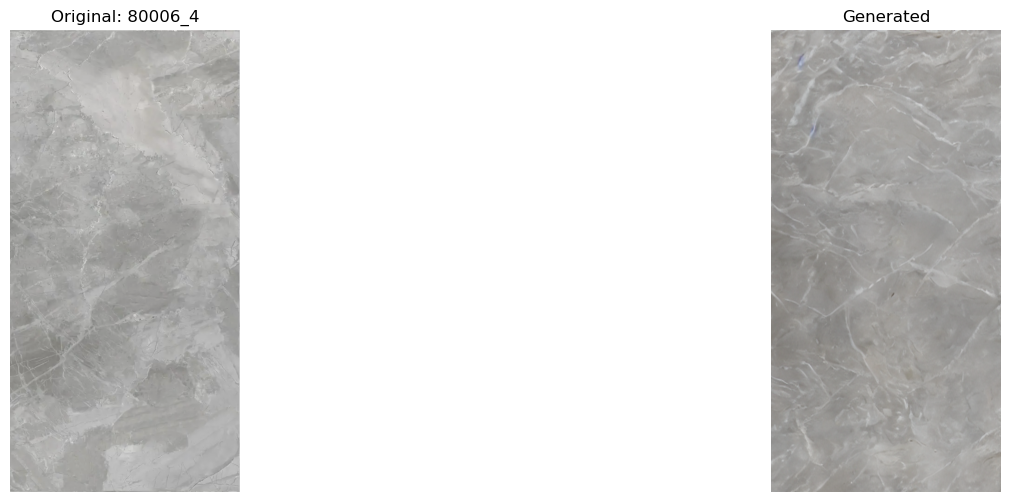

  0%|          | 0/30 [00:00<?, ?it/s]

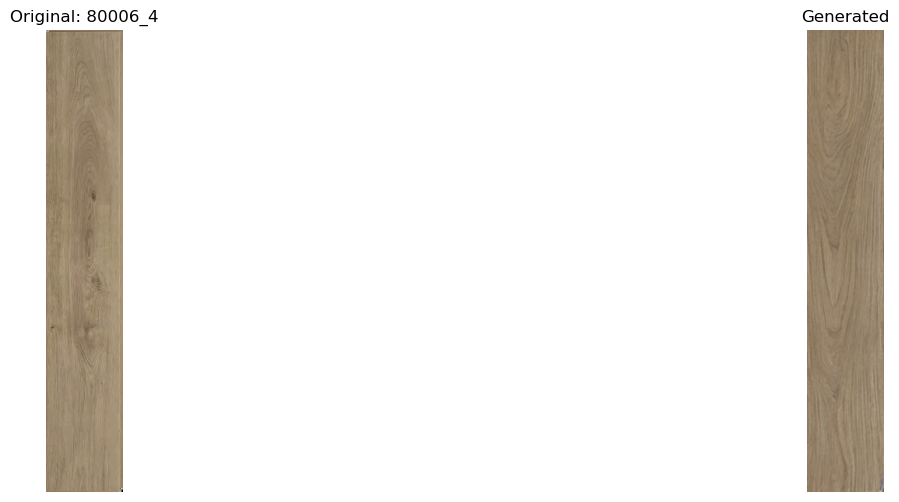

In [49]:
from PIL import Image

prompt = "porcelain"
    
init_image = init_image = Image.open("../data/test/stone.png").convert("RGB")
original_size = init_image.size 
init_image_resized = init_image.resize((512, 512))

images = pipe(prompt=prompt, image=init_image_resized, strength=0.6, guidance_scale=7.5).images
generated_image_resized = images[0].resize(original_size)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(init_image)
axes[0].set_title(f"Original: {test_dataset[i]['name1']}")
axes[0].axis("off")

axes[1].imshow(generated_image_resized)
axes[1].set_title("Generated")
axes[1].axis("off")

plt.show()


prompt = "wooden laminate"
    
init_image = init_image = Image.open("../data/test/wood.png").convert("RGB")
original_size = init_image.size 
init_image_resized = init_image.resize((512, 512))

images = pipe(prompt=prompt, image=init_image_resized, strength=0.6, guidance_scale=7.5).images
generated_image_resized = images[0].resize(original_size)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(init_image)
axes[0].set_title(f"Original: {test_dataset[i]['name1']}")
axes[0].axis("off")

axes[1].imshow(generated_image_resized)
axes[1].set_title("Generated")
axes[1].axis("off")

plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

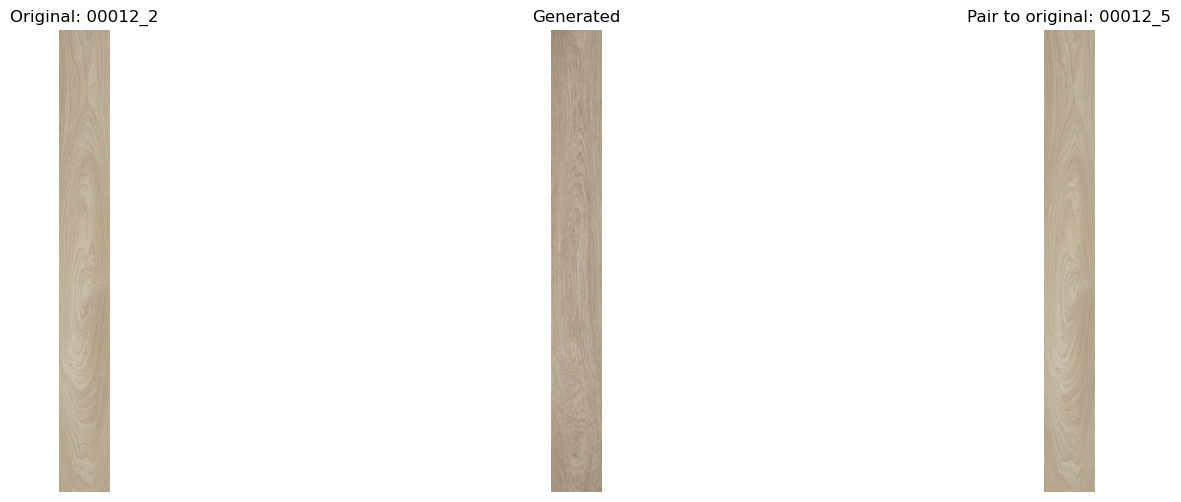

  0%|          | 0/30 [00:00<?, ?it/s]

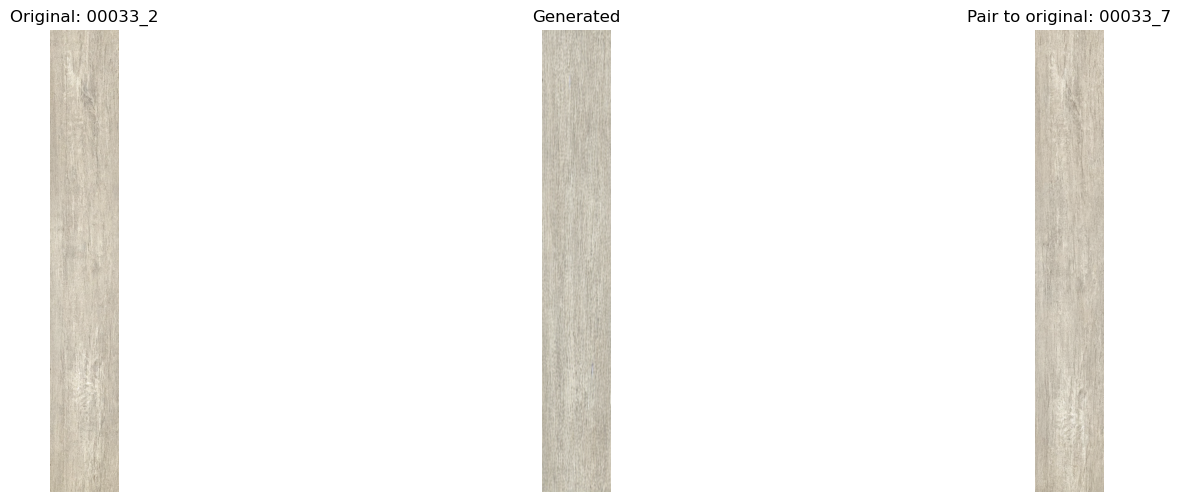

  0%|          | 0/30 [00:00<?, ?it/s]

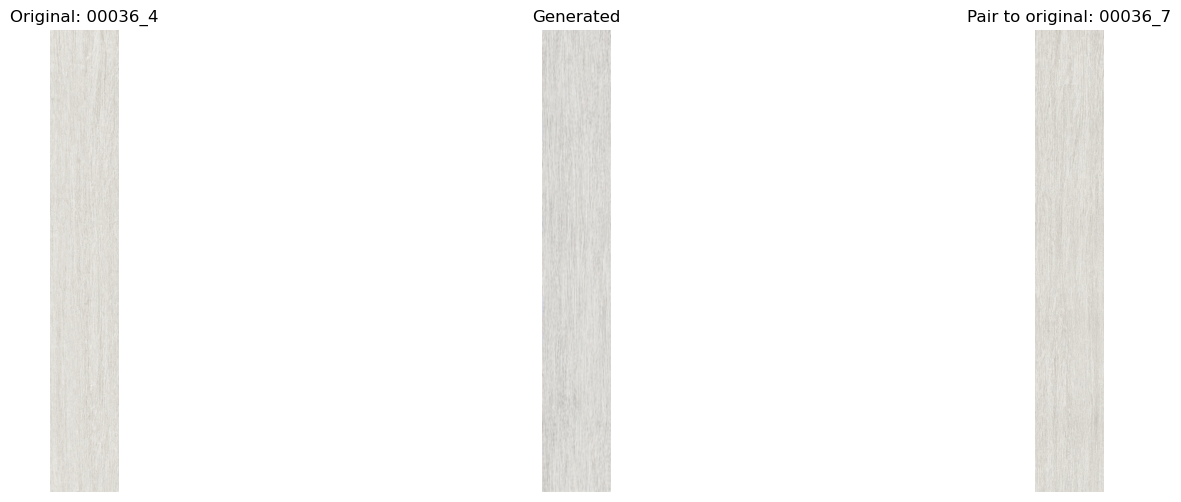

  0%|          | 0/30 [00:00<?, ?it/s]

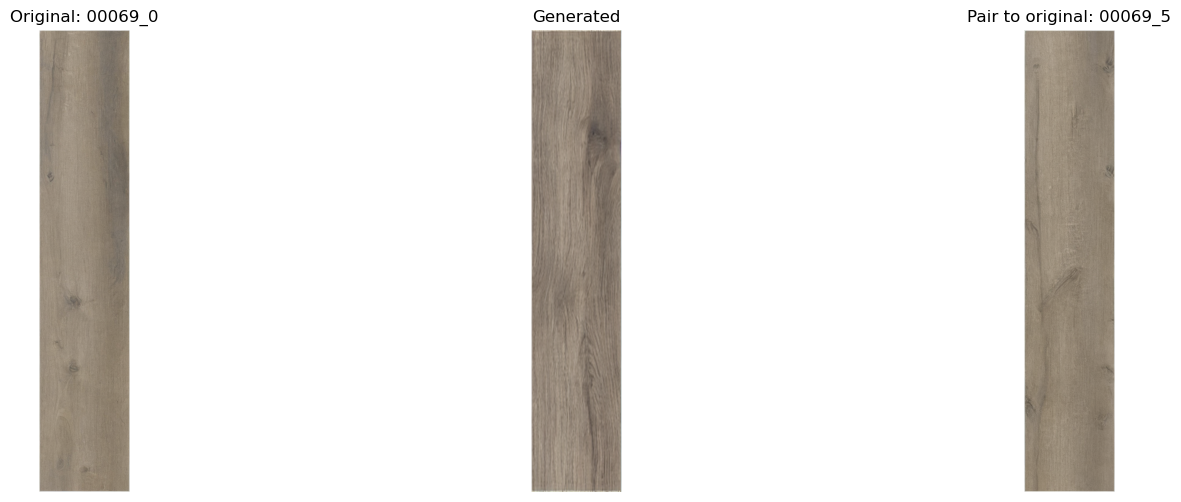

  0%|          | 0/30 [00:00<?, ?it/s]

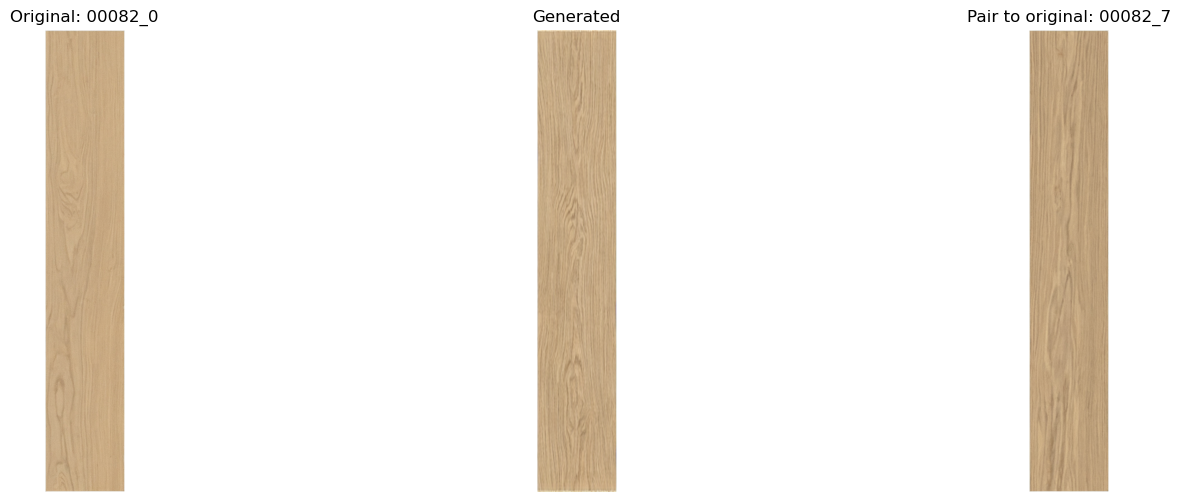

  0%|          | 0/30 [00:00<?, ?it/s]

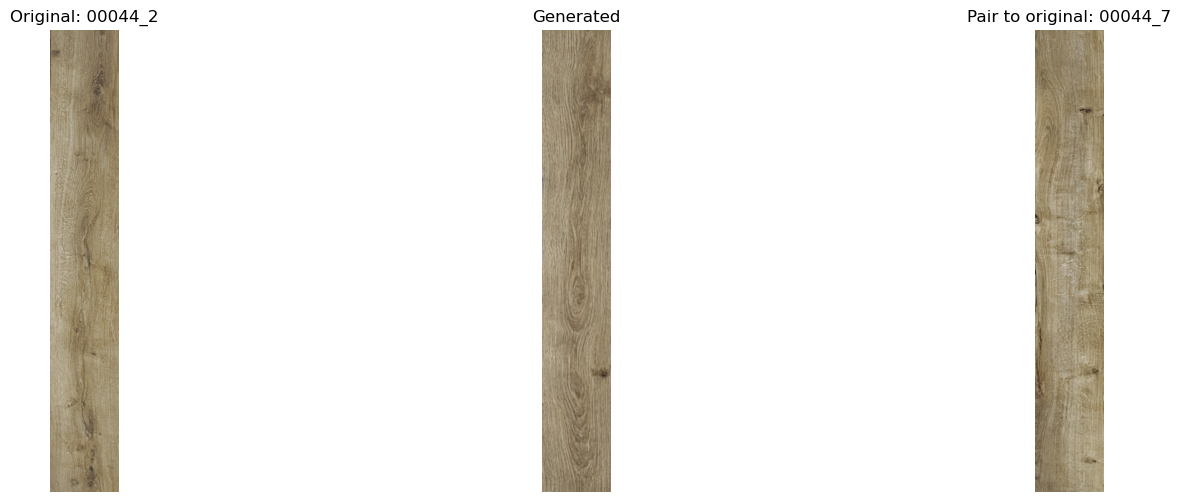

  0%|          | 0/30 [00:00<?, ?it/s]

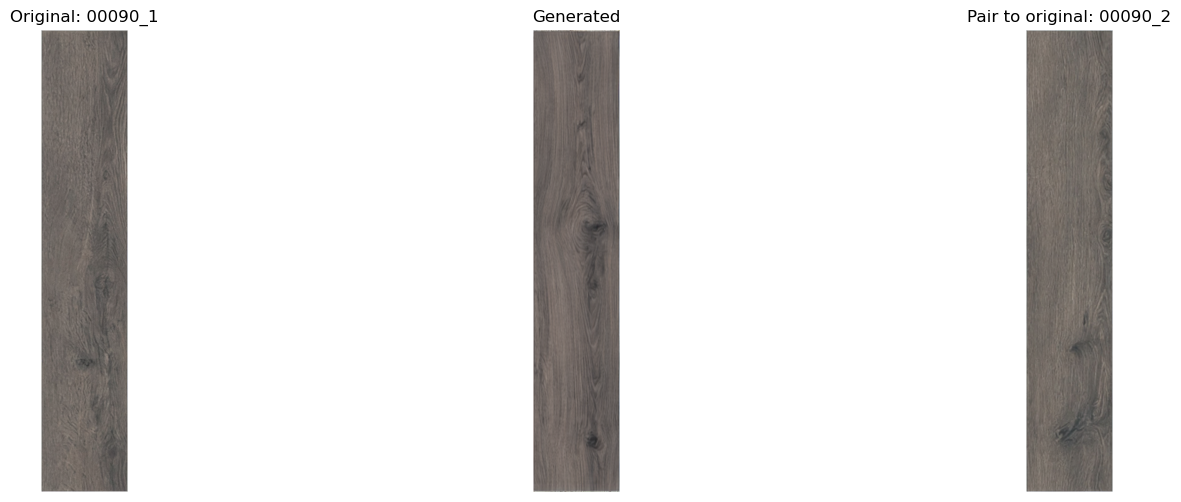

  0%|          | 0/30 [00:00<?, ?it/s]

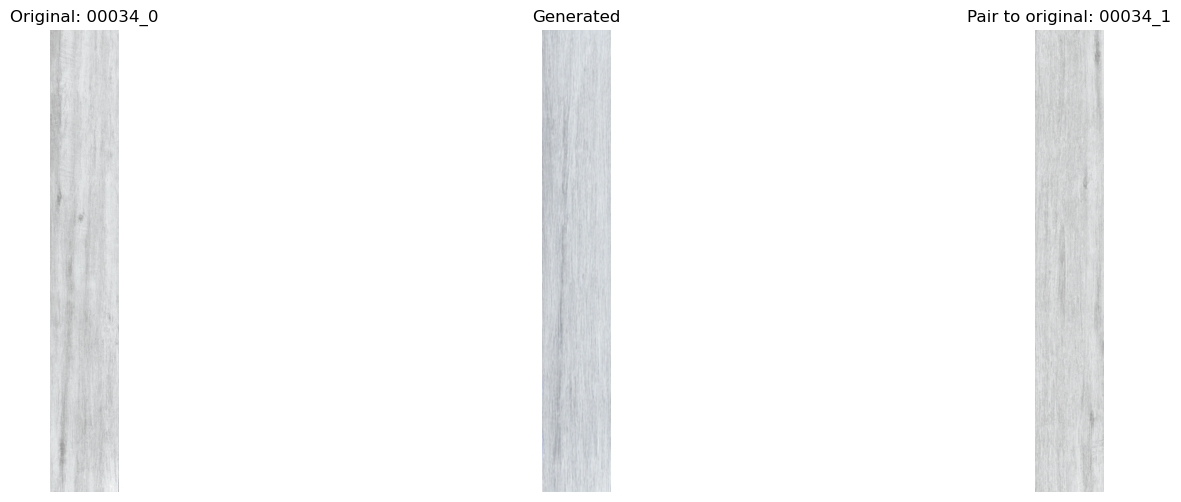

  0%|          | 0/30 [00:00<?, ?it/s]

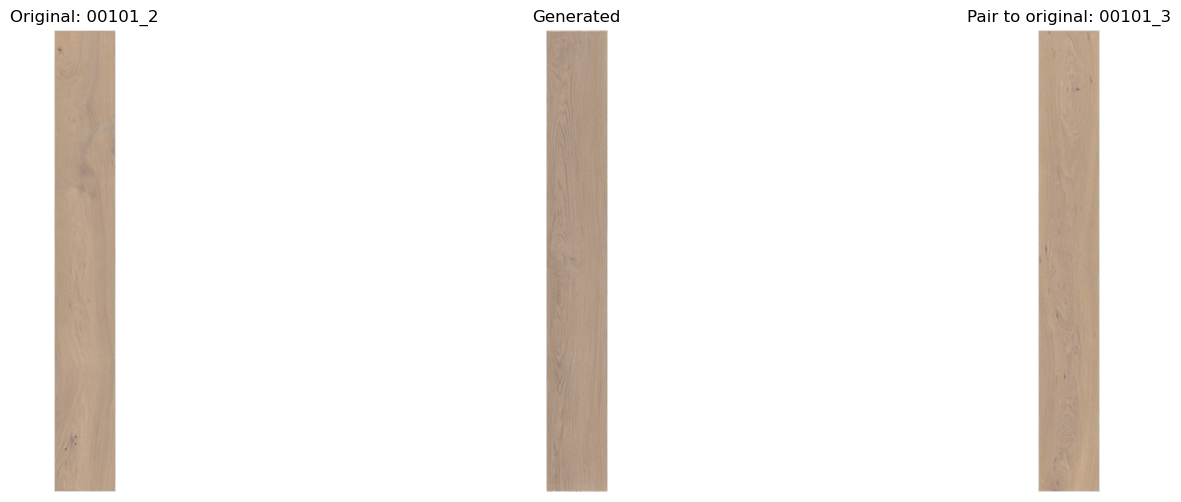

  0%|          | 0/30 [00:00<?, ?it/s]

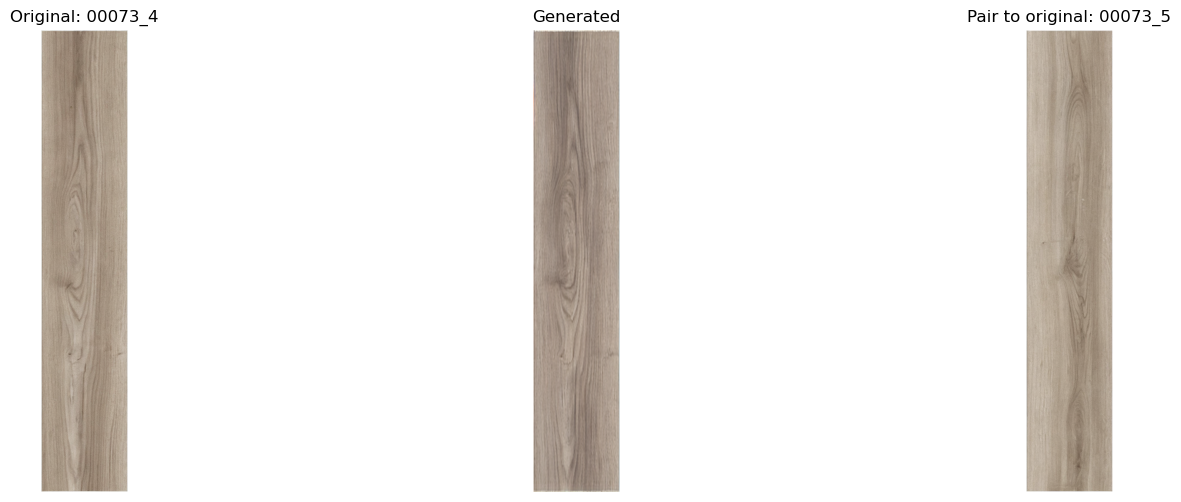

  0%|          | 0/30 [00:00<?, ?it/s]

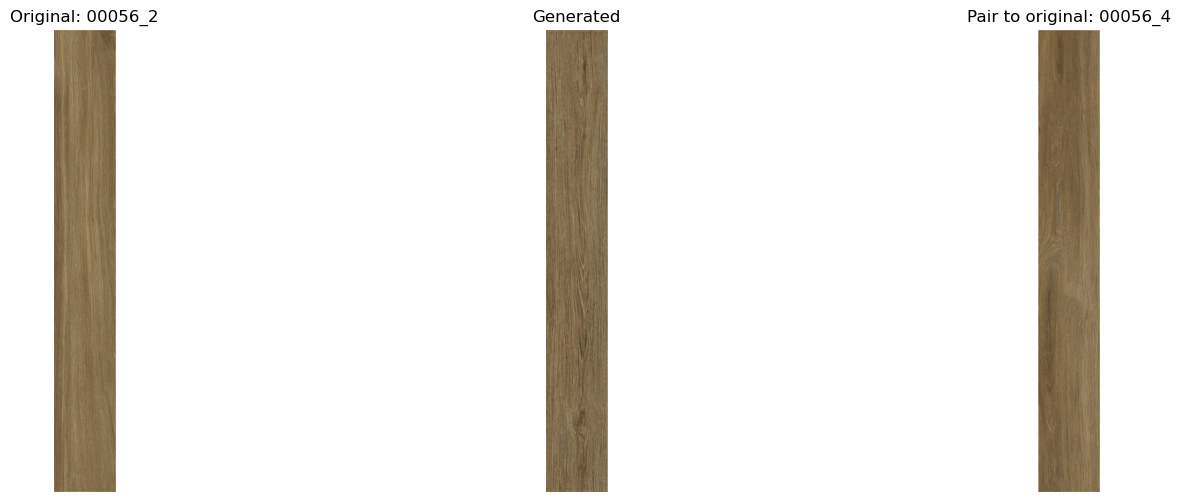

  0%|          | 0/30 [00:00<?, ?it/s]

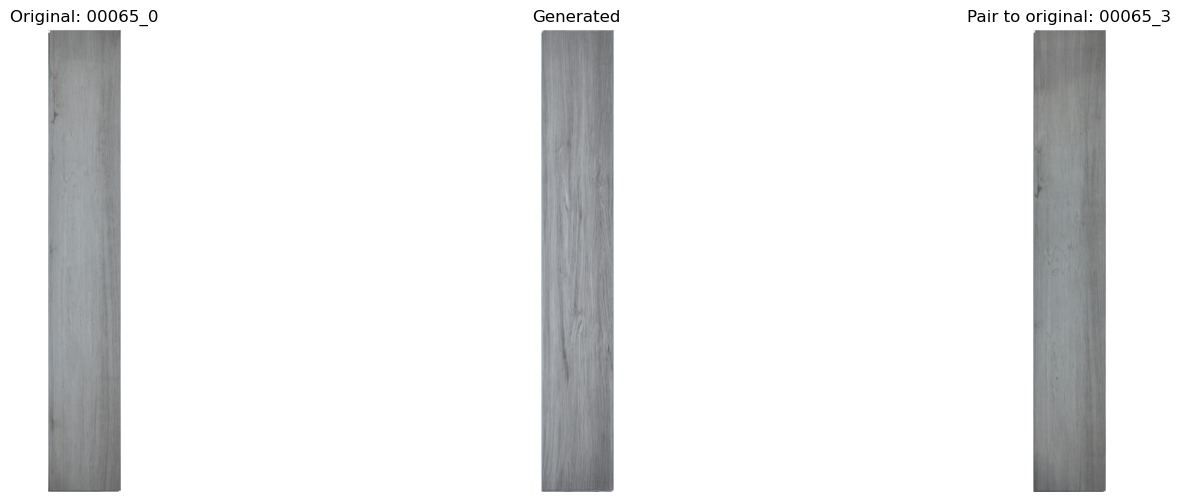

  0%|          | 0/30 [00:00<?, ?it/s]

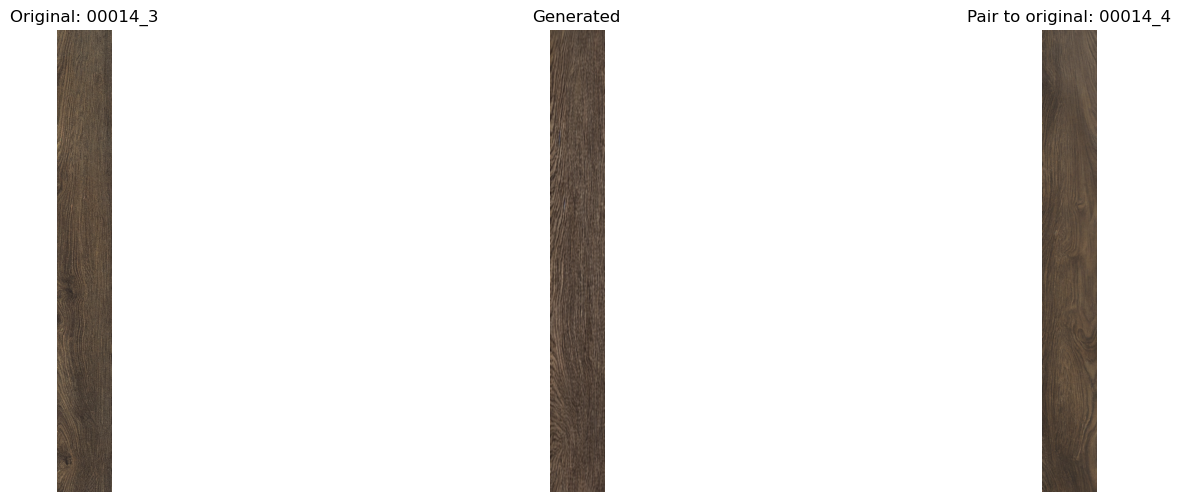

  0%|          | 0/30 [00:00<?, ?it/s]

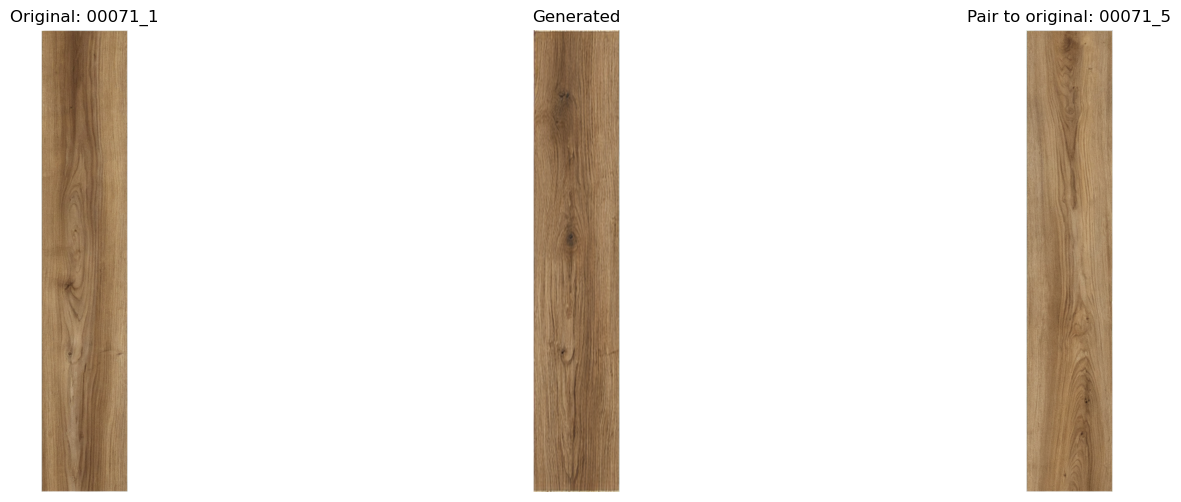

  0%|          | 0/30 [00:00<?, ?it/s]

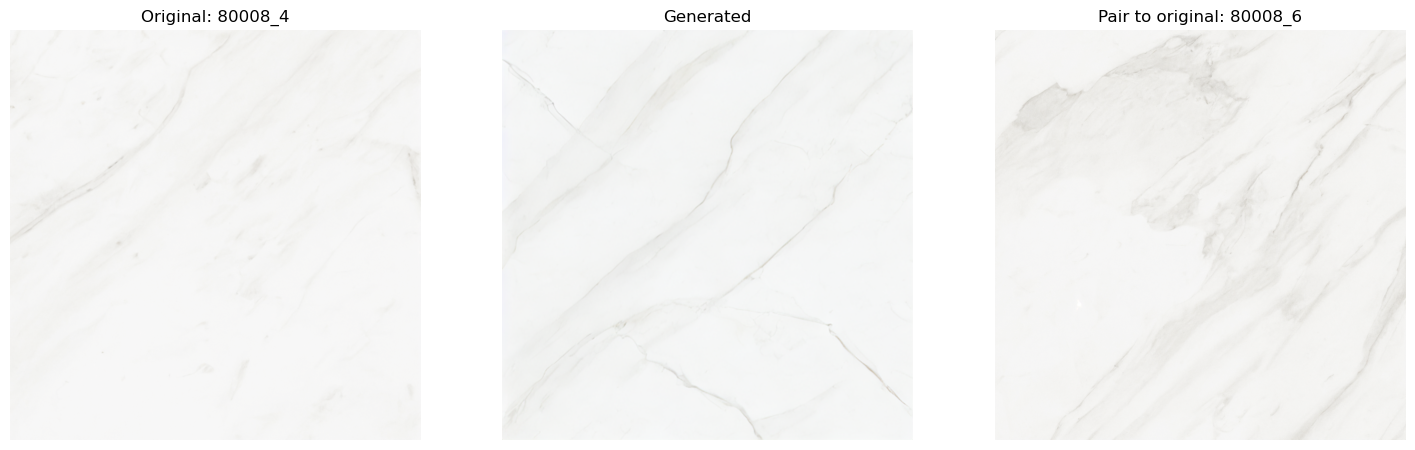

  0%|          | 0/30 [00:00<?, ?it/s]

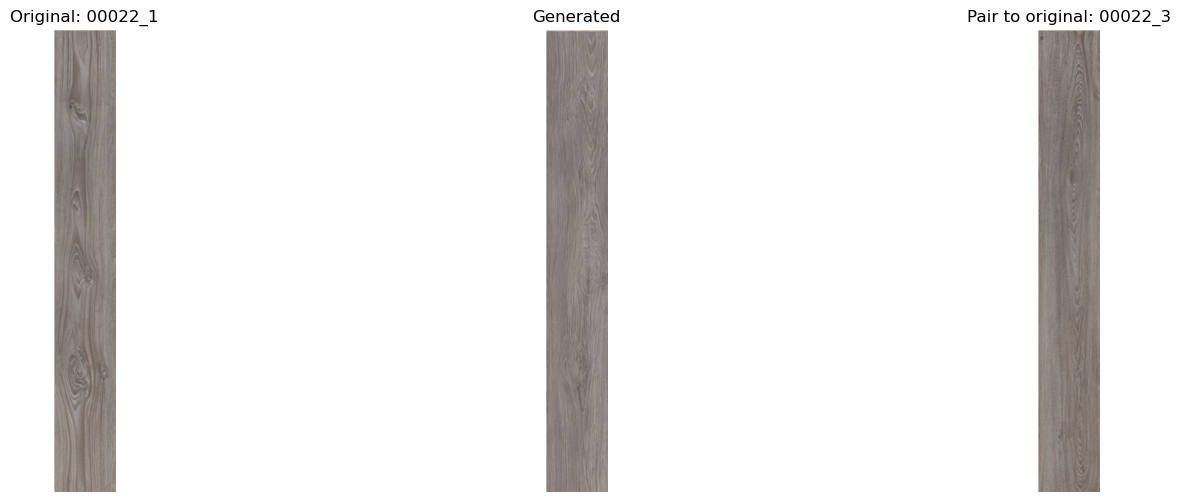

  0%|          | 0/30 [00:00<?, ?it/s]

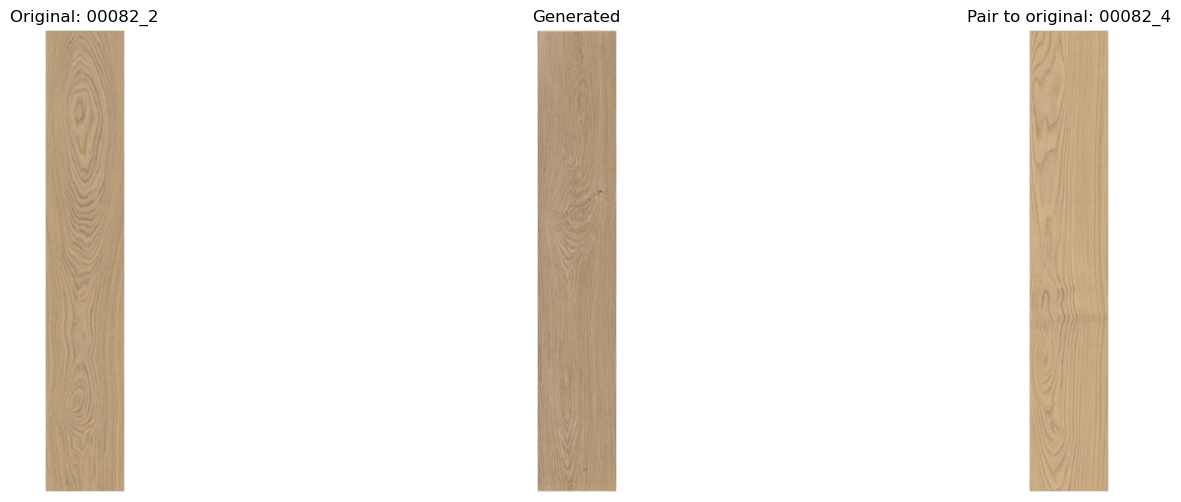

  0%|          | 0/30 [00:00<?, ?it/s]

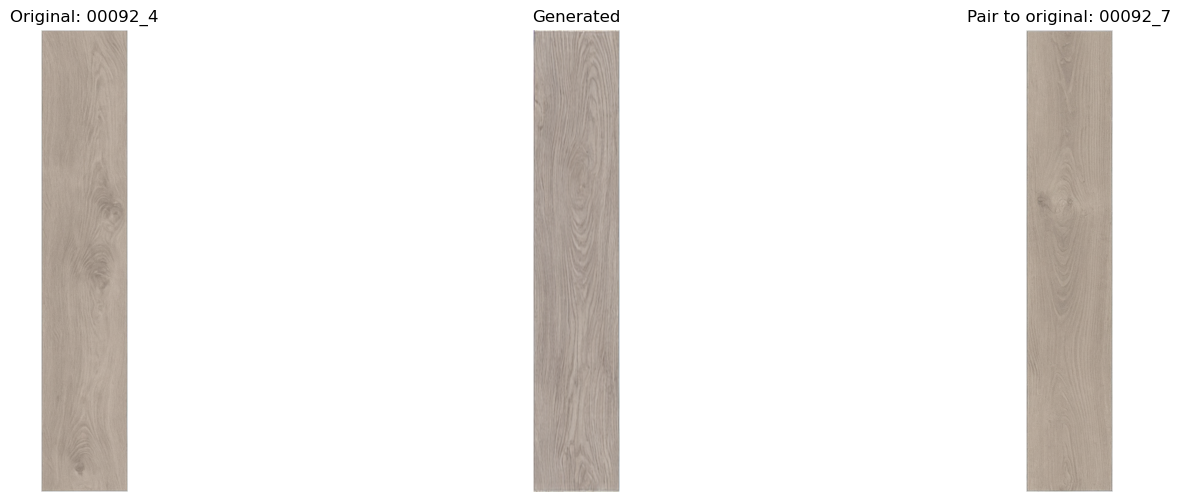

  0%|          | 0/30 [00:00<?, ?it/s]

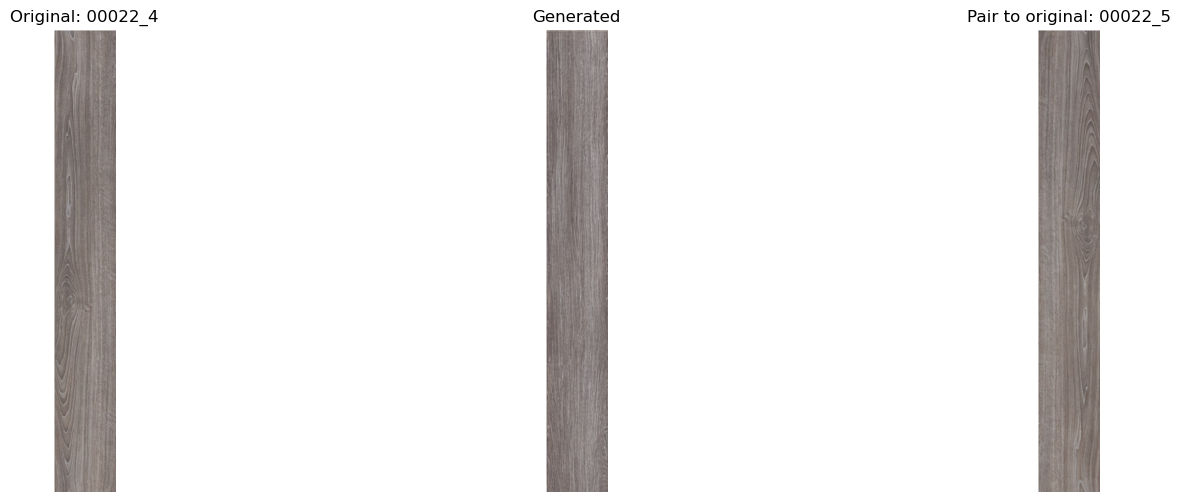

  0%|          | 0/30 [00:00<?, ?it/s]

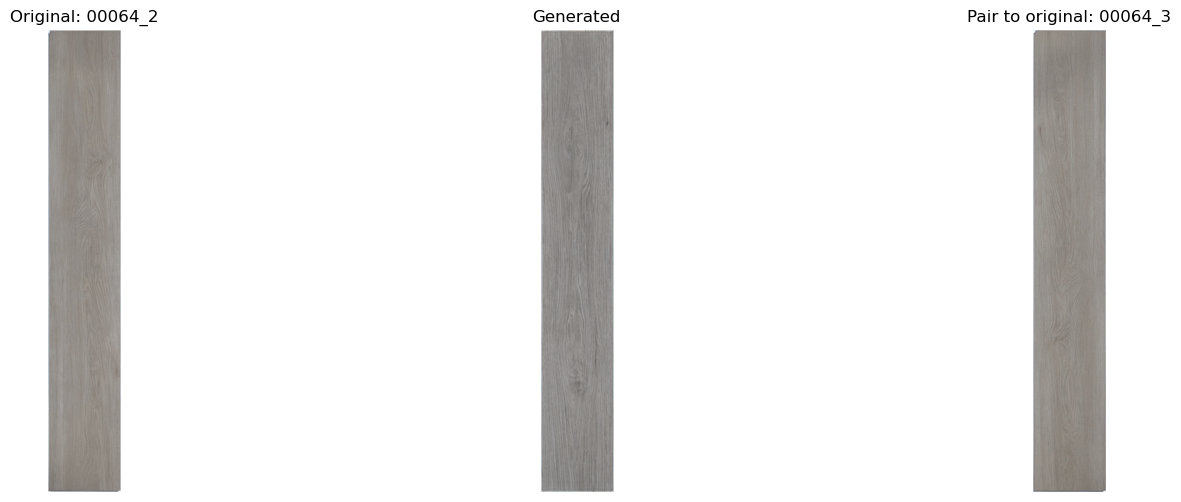

  0%|          | 0/30 [00:00<?, ?it/s]

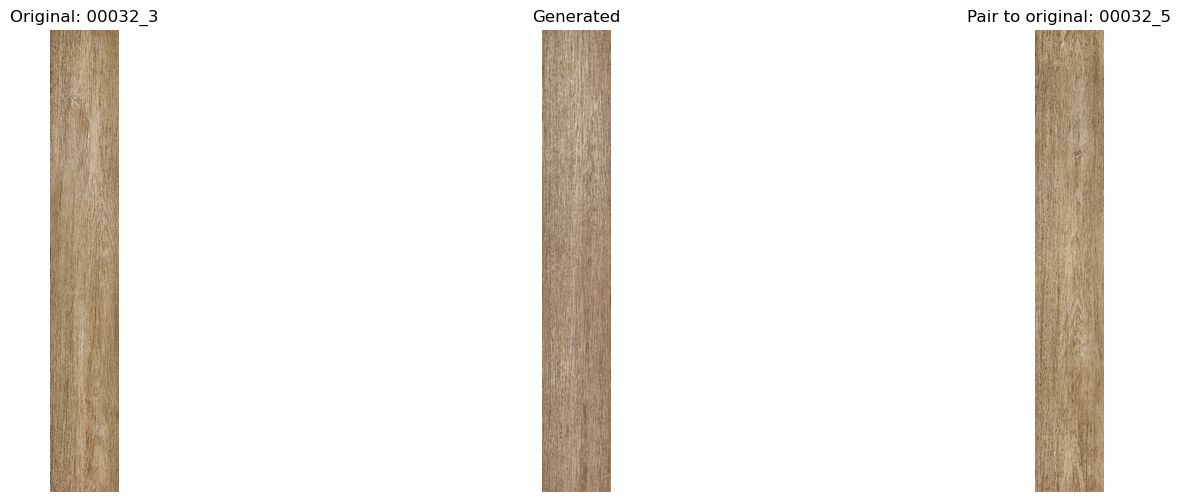

  0%|          | 0/30 [00:00<?, ?it/s]

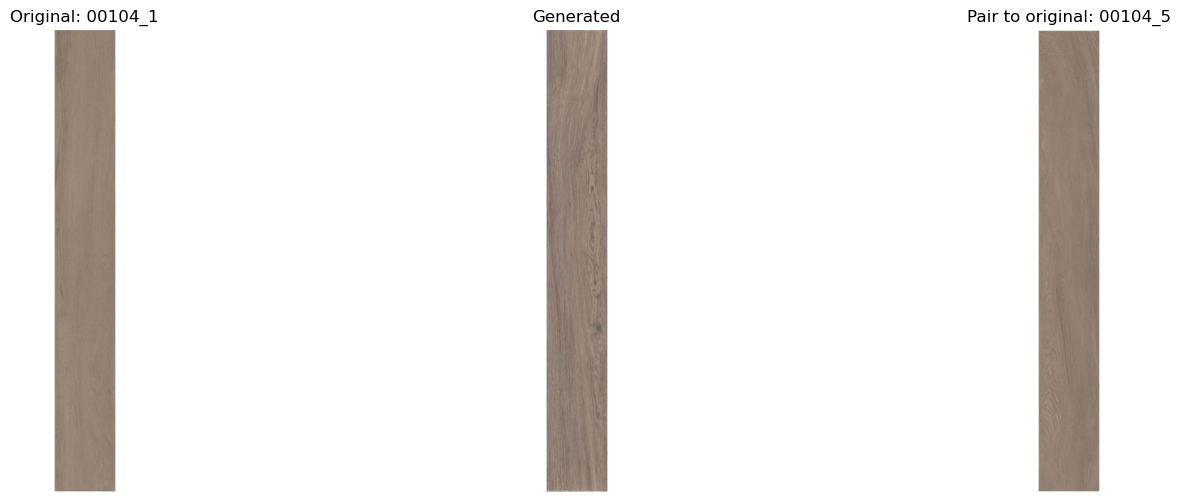

  0%|          | 0/30 [00:00<?, ?it/s]

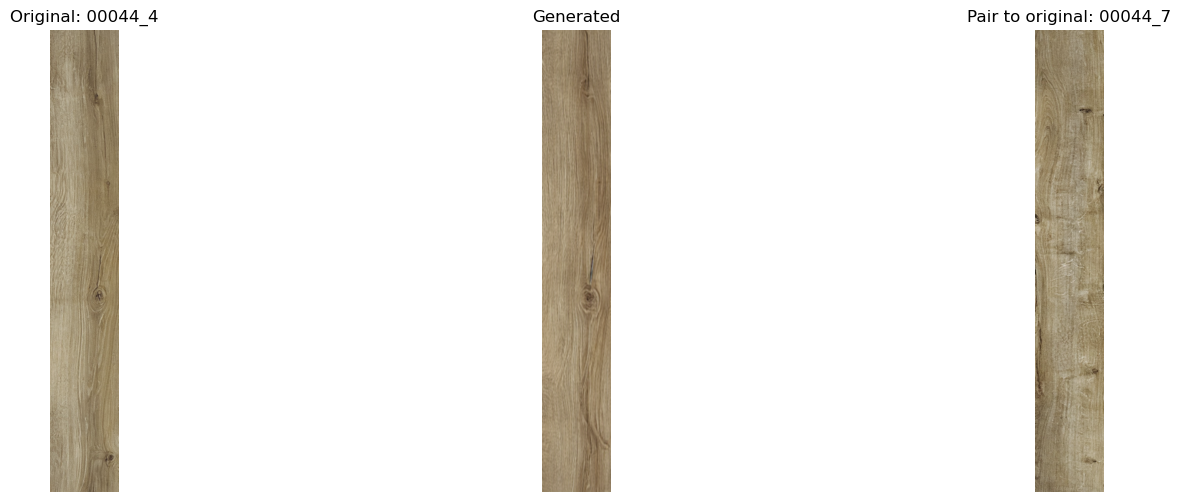

  0%|          | 0/30 [00:00<?, ?it/s]

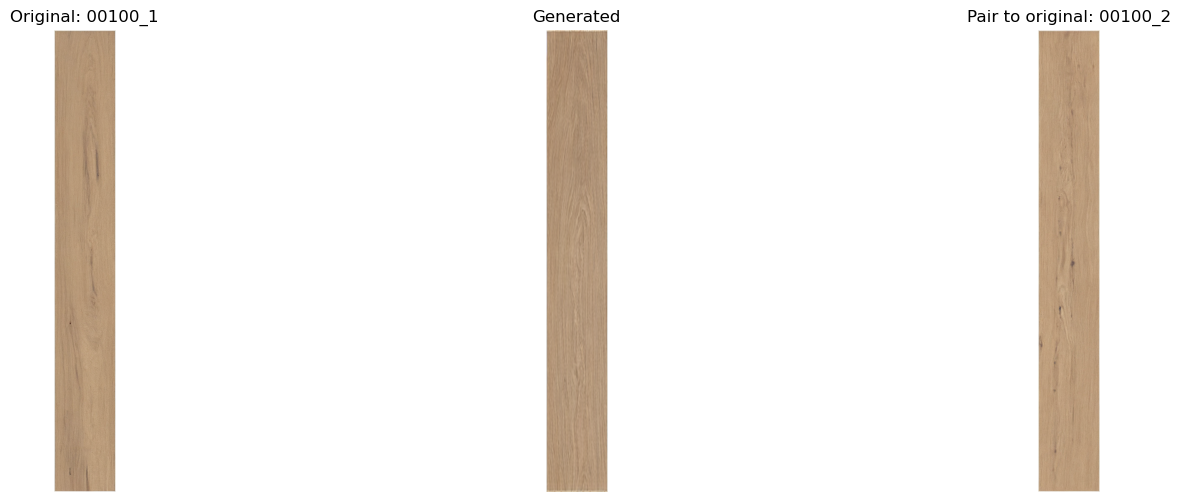

  0%|          | 0/30 [00:00<?, ?it/s]

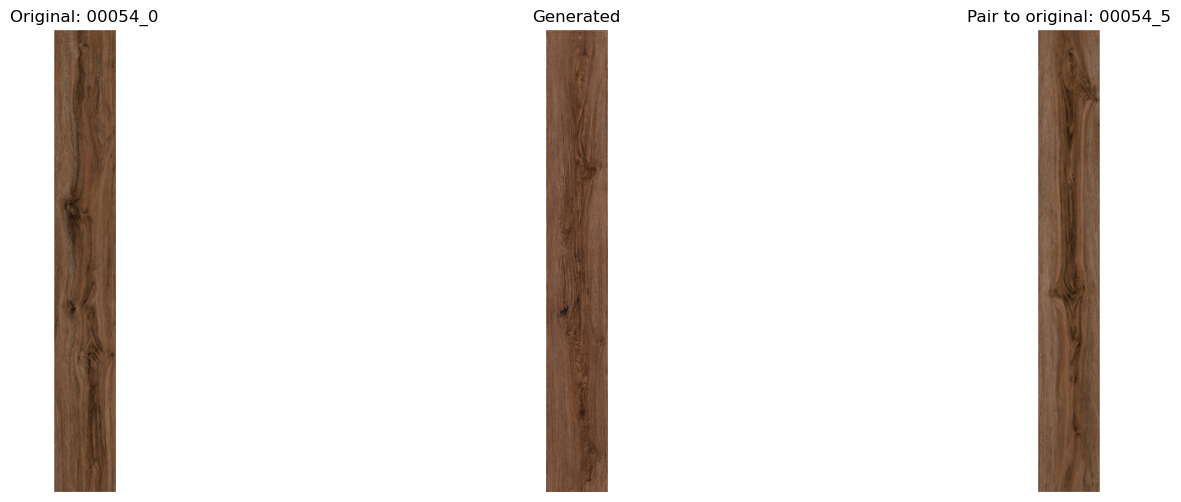

  0%|          | 0/30 [00:00<?, ?it/s]

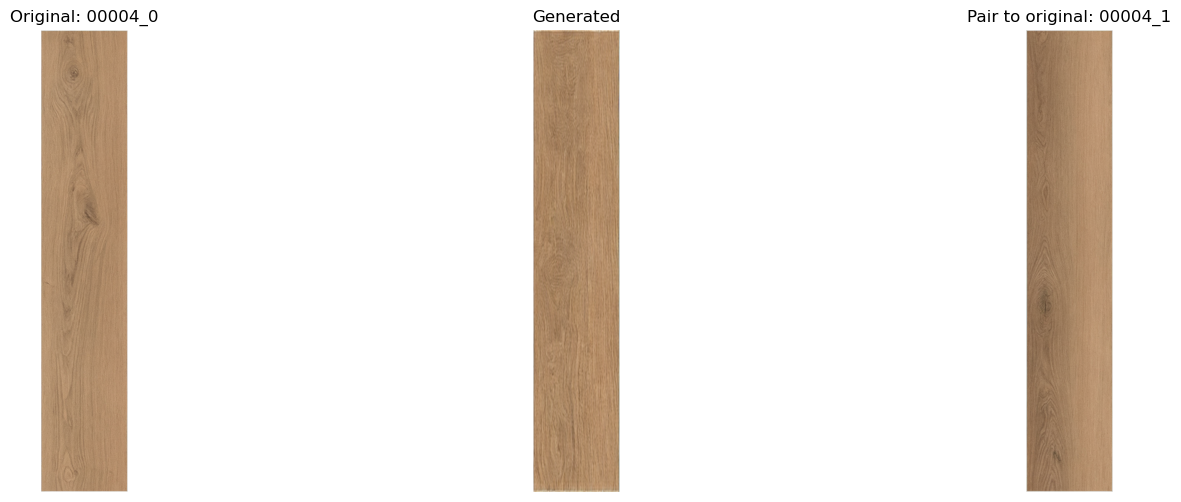

  0%|          | 0/30 [00:00<?, ?it/s]

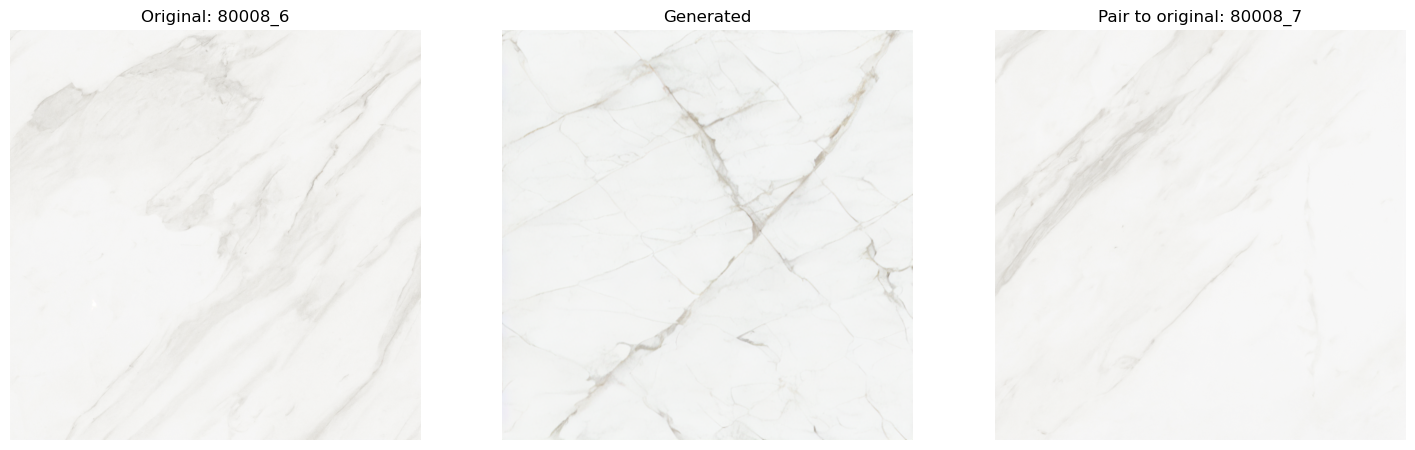

  0%|          | 0/30 [00:00<?, ?it/s]

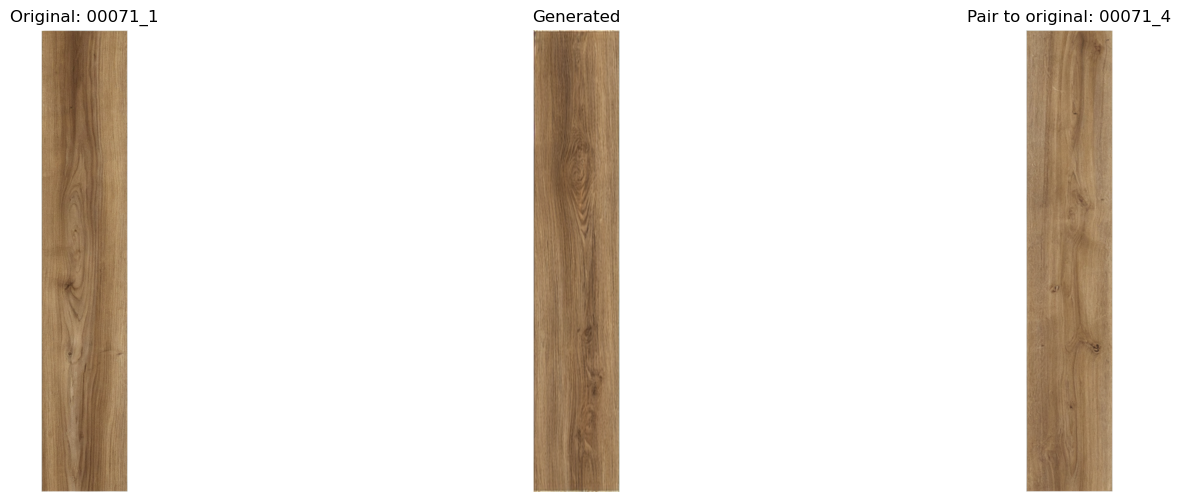

  0%|          | 0/30 [00:00<?, ?it/s]

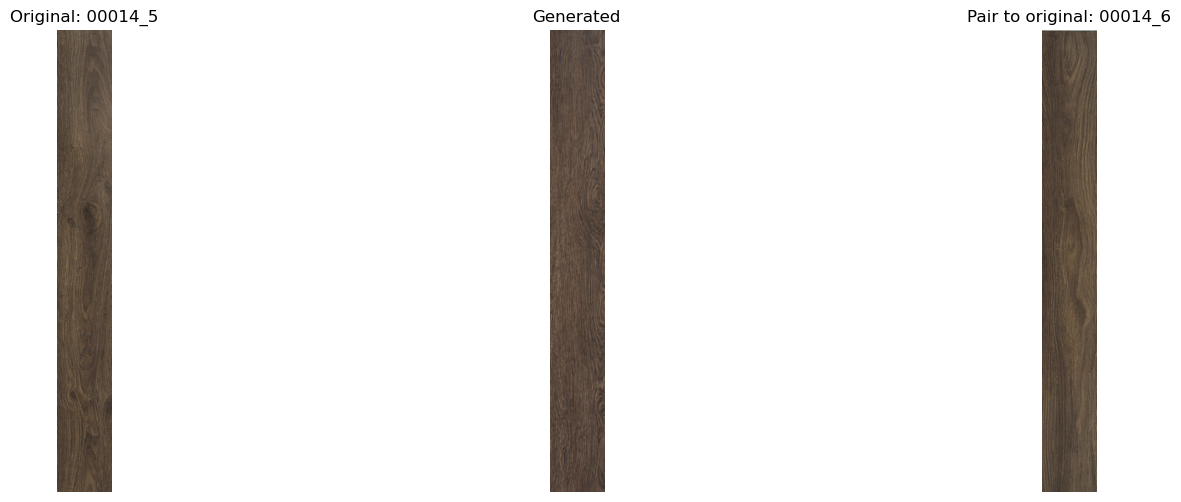

  0%|          | 0/30 [00:00<?, ?it/s]

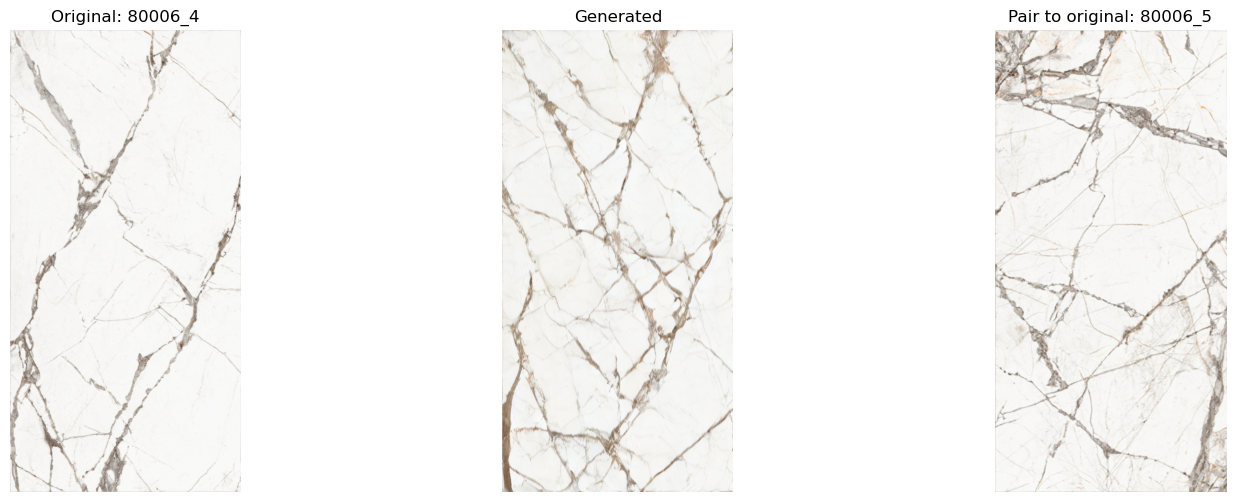

123.69564700126648


In [24]:
import time
import matplotlib.pyplot as plt

start_time = time.time()

for i in range(30):
    # print(test_dataset[i])
    image_id = int(test_dataset[i]["name1"].split('_')[0])
    if image_id < 60_001: prompt = "wooden laminate"
    elif image_id < 90_001: prompt = "stone laminate"
    elif image_id < 99_999: prompt = "one decorative tile"
        
    init_image = test_dataset[i]['image1']
    original_size = init_image.size 
    init_image_resized = init_image.resize((512, 512))

    images = pipe(prompt=prompt, image=init_image_resized, strength=0.6, guidance_scale=7.5).images
    generated_image_resized = images[0].resize(original_size)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(init_image)
    axes[0].set_title(f"Original: {test_dataset[i]['name1']}")
    axes[0].axis("off")

    axes[1].imshow(generated_image_resized)
    axes[1].set_title("Generated")
    axes[1].axis("off")

    axes[2].imshow(test_dataset[i]['image2'])
    axes[2].set_title(f"Pair to original: {test_dataset[i]['name2']}")
    axes[2].axis("off")

    plt.show()


print(time.time() - start_time)